# **Predictive Logistics Model Analysis**

*This notebook aims to demonstrate a machine learning pipeline that predicts whether a given shipment will be delayed or delivered on time, and estimates the exact delay duration.*

*The model trains on logistics variables such as vehicle speed, weather conditions, traffic index, warehouse backlog, and distance remaining.*

### 1. Import Essential Libraries
First, we load the required Python libraries for data manipulation and visualization.
`numpy` and `pandas` are used to handle the dataset, while `matplotlib` provides robust graphing capabilities.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Exploring the dataset
We will load our logistics dataset from the CSV file to inspect the raw data structure.

### 2. Loading Data
Using `pandas.read_csv`, we ingest the training data into a DataFrame.

In [4]:
# Loading the dataset
df = pd.read_csv(r'/content/training_data.csv')

### 3. Dataset Dimensionality
Let's see how many rows (records) and columns (features) exist within the dataset.

In [5]:
# Returns number of rows and columns of the dataset
df.shape

(1000, 7)

### 4. Exploring Features
Outputs all the column names to verify that our expected logistics factors (speed, weather, delay targets) are present.

In [6]:
# Returns an object with all of the column headers
df.columns

Index(['current_speed_kmh', 'weather_condition', 'traffic_index',
       'warehouse_backlog_index', 'distance_remaining', 'is_delayed',
       'delay_minutes'],
      dtype='object')

### 5. Datatype Inspection
It's crucial to understand the data type of each variable. We check for numerical types (`int`, `float`) versus object types (`str`) which will require encoding before model training.

In [7]:
# Returns different datatypes for each column
df.dtypes

,0
current_speed_kmh,float64
weather_condition,object
traffic_index,int64
warehouse_backlog_index,int64
distance_remaining,float64
is_delayed,int64
delay_minutes,int64


### 6. Peek at the Data
Print the first 5 records of the dataset to get a visual sense of the raw values.

In [8]:
# Returns the first 5 rows
df.head()

,current_speed_kmh,weather_condition,traffic_index,warehouse_backlog_index,distance_remaining,is_delayed,delay_minutes
0,36.2,Storm,3,6,235.08,1,27
1,53.5,Rain,2,6,5.04,0,0
2,57.2,Clear,5,6,114.91,0,0
3,66.3,Clear,3,1,117.00,0,0
4,27.2,Storm,6,4,182.62,1,57


### 7. Core Properties
We fetch a summary of the non-null counts to quickly identify if there's any missing data in any column.

In [9]:
# Returns basic information on all columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   current_speed_kmh        1000 non-null   float64
 1   weather_condition        1000 non-null   object 
 2   traffic_index            1000 non-null   int64  
 3   warehouse_backlog_index  1000 non-null   int64  
 4   distance_remaining       1000 non-null   float64
 5   is_delayed               1000 non-null   int64  
 6   delay_minutes            1000 non-null   int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 54.8+ KB


### 8. Statistical Summary
Generate descriptive statistics for all numerical columns such as the mean, standard deviation, and quartiles. This helps spot anomalies or extreme outliers.

In [10]:
# Returns basic statistics on numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
current_speed_kmh,1000.0,37.72260,16.994498,6.30,24.4750,35.30,48.4000,83.90
traffic_index,1000.0,5.44500,2.923957,1.00,3.0000,5.00,8.0000,10.00
warehouse_backlog_index,1000.0,5.54900,2.870163,1.00,3.0000,6.00,8.0000,10.00
distance_remaining,1000.0,154.35834,85.781270,5.04,81.2425,159.02,229.2175,299.21
is_delayed,1000.0,0.58300,0.493310,0.00,0.0000,1.00,1.0000,1.00
delay_minutes,1000.0,30.91200,29.381006,0.00,0.0000,33.00,55.0000,110.00


### 9. Missing Value Check
Executing a final strict check to confirm whether any column contains `Null` or `NaN` values that would require imputation.

In [11]:
# Returns true for a column having null values
df.isnull().any()

,0
current_speed_kmh,False
weather_condition,False
traffic_index,False
warehouse_backlog_index,False
distance_remaining,False
is_delayed,False
delay_minutes,False


## Data Visualization
We visualize to observe class distributions and potential relationships prior to processing.

### 10. Class Balance Assessment
We plot the distribution of our primary target variable, `is_delayed`. This helps us understand whether our dataset is imbalanced (e.g. mostly on-time deliveries) which could bias our model.

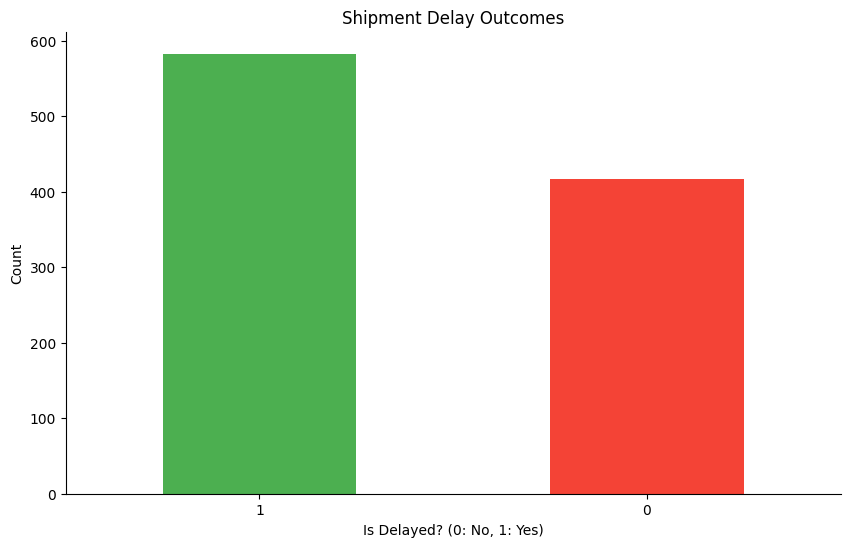

In [12]:
# Plotting the Outcomes based on the number of dataset entries
plt.figure(figsize=(10,6))
ax = df['is_delayed'].value_counts().plot(kind='bar', color=['#4CAF50', '#F44336'])

# Removing the unwanted spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Headings
plt.title('Shipment Delay Outcomes')
plt.xlabel('Is Delayed? (0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

### 11. Delay Magnitude Distribution
For shipments that *are* delayed, what is the frequency distribution of the delay duration? We visualize the `delay_minutes` attribute using a histogram.

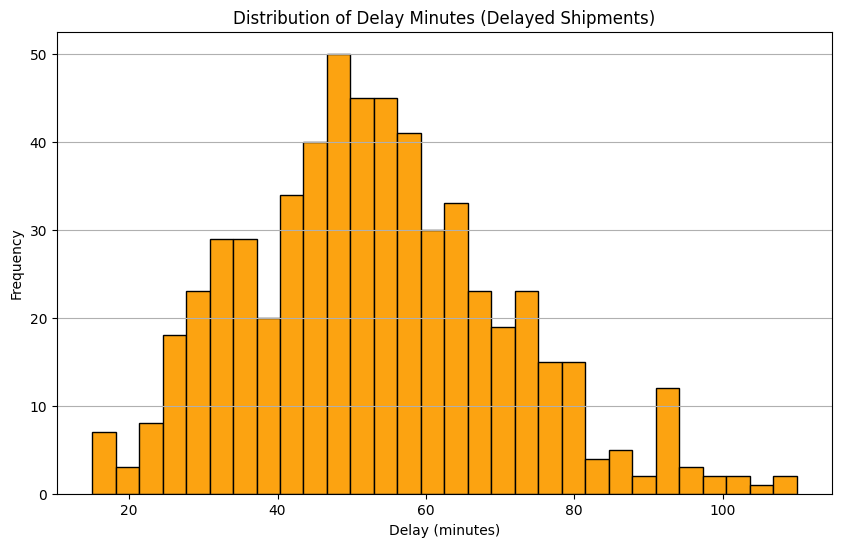

In [13]:
# Plotting the delay minutes distribution for delayed shipments
plt.figure(figsize=(10, 6))
df[df['is_delayed'] == 1]['delay_minutes'].hist(bins=30, color='#fca311', edgecolor='black')
plt.title("Distribution of Delay Minutes (Delayed Shipments)")
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")
plt.grid(axis='x')
plt.show()

## Data Preprocessing

### 12. Label Encoding Categorical Variables
Machine learning models perform math matrix operations and therefore cannot process strings. We use `LabelEncoder` to convert the categorical `weather_condition` labels (e.g. 'Clear', 'Rain') into numerical factors.

In [14]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical feature (Weather Condition)
le = LabelEncoder()
df["weather_encoded"] = le.fit_transform(df["weather_condition"])

df[['weather_condition', 'weather_encoded']].head()

,weather_condition,weather_encoded
0,Storm,4
1,Rain,3
2,Clear,0
3,Clear,0
4,Storm,4


### 13. Feature Lineup & Correlation Matrix
We group our features together and build a Pearson correlation matrix.
This heatmap visually identifies linearly correlated features. For example, we can check if high traffic indices strongly align with the `is_delayed` attribute, hinting at predictive importance.

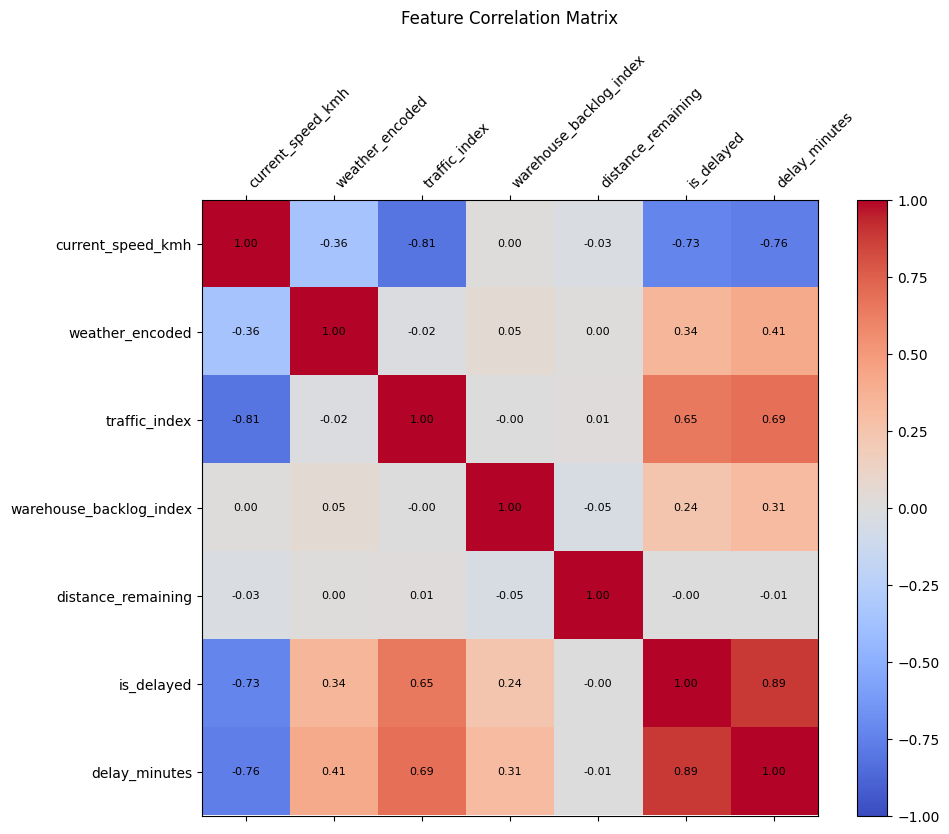

In [15]:
feature_cols = [
    "current_speed_kmh",
    "weather_encoded",
    "traffic_index",
    "warehouse_backlog_index",
    "distance_remaining",
]

# Correlation Matrix
fig, ax = plt.subplots(figsize=(10, 8))
corr_cols = feature_cols + ['is_delayed', 'delay_minutes']
corr = df[corr_cols].corr()

# Use ax.matshow instead of plt.matshow
cax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)

# Set ticks
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))

# Rotate labels
ax.set_xticklabels(corr_cols, rotation=45, ha='left')
ax.set_yticklabels(corr_cols)

# Annotate
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)

plt.title("Feature Correlation Matrix", pad=20)
plt.show()

## Model Building
Now we construct the AI Engine. We will utilize XGBoost, a powerful, state-of-the-art gradient boosting framework.

### 14. Train-Test Split
We split the dataset using an 80/20 ratio.
80% of our data trains the AI to recognize patterns, while the remaining 20% is held back to 'test' the model's accuracy on unseen data.

In [16]:
from sklearn.model_selection import train_test_split

X = df[feature_cols].values
y_class = df["is_delayed"].values
y_reg = df["delay_minutes"].values

X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42
)
print('X_train size: {}, X_test size: {}'.format(X_train.shape, X_test.shape))

X_train size: (800, 5), X_test size: (200, 5)


### 15. Import Evaluation & AI Modules

In [17]:
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import accuracy_score, mean_absolute_error, confusion_matrix

### 16. Train Probability Classifier
We define the `XGBClassifier` and instruct it to learn the probability of a delay (`is_delayed`) occurring given our train attributes.

In [18]:
# Classifier (Delay Probability)
clf = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss",
)
clf.fit(X_train, yc_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

### 17. Evaluate Classifier Accuracy
We trigger the model to make predictions across the 20% test-set and establish its overall accuracy percentage by comparing results to ground truth.

In [19]:
# Model Evaluation (Classification)
yc_pred = clf.predict(X_test)
acc = accuracy_score(yc_test, yc_pred)
print(f"Classifier Accuracy: {acc:.2%}")

Classifier Accuracy: 91.00%


### 18. Confusion Matrix
A structured chart measuring the true-positives, true-negatives, false-positives, and false-negatives in our delay predictions. This exposes *where* the model fails (i.e. predicting delay when there wasn't one).

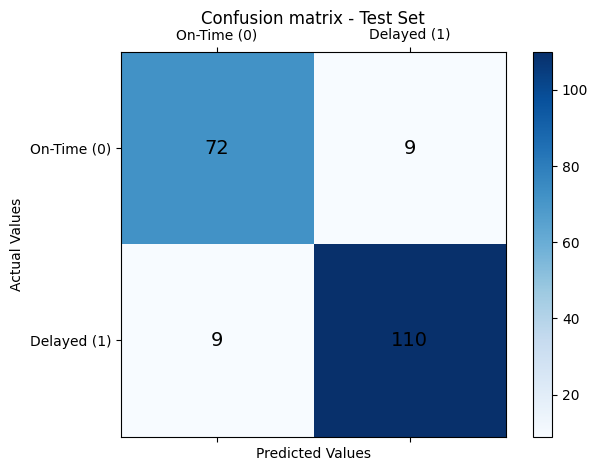

In [20]:
# Confusion Matrix
cm = confusion_matrix(yc_test, yc_pred)

fig, ax = plt.subplots(figsize=(7,5))
cax = ax.matshow(cm, cmap='Blues')
fig.colorbar(cax)

# Annotate
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}", ha='center', va='center', color='black', fontsize=14)

plt.title('Confusion matrix - Test Set', pad=20)
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Actual Values')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['On-Time (0)', 'Delayed (1)'])
ax.set_yticklabels(['On-Time (0)', 'Delayed (1)'])
plt.show()

### 19. Train Duration Regressor
If the shipment is delayed, we need to know *by how much*. We fit an `XGBRegressor` to target the `delay_minutes` attribute directly.

In [21]:
# Regressor (Delay Duration)
reg = XGBRegressor(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
)
reg.fit(X_train, yr_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=150,
             n_jobs=None, num_parallel_tree=None, ...)

### 20. Evaluate Regressor
We evaluate the output by determining the Mean Absolute Error (MAE) which represents, on average, how many minutes the model was off by.

In [22]:
# Model Evaluation (Regression)
yr_pred = reg.predict(X_test)
mae = mean_absolute_error(yr_test, yr_pred)
print(f"Regressor Mean Absolute Error: {mae:.1f} minutes")

Regressor Mean Absolute Error: 10.7 minutes


## Feature Importance

### 21. Plot Feature Importance Weights
One of the most valuable aspects of XGBoost is extracting its decision logic. We parse out the `feature_importances_` array to build a bar chart revealing precisely which logistics variable holds the most mathematical weight when the engine makes its predictions.

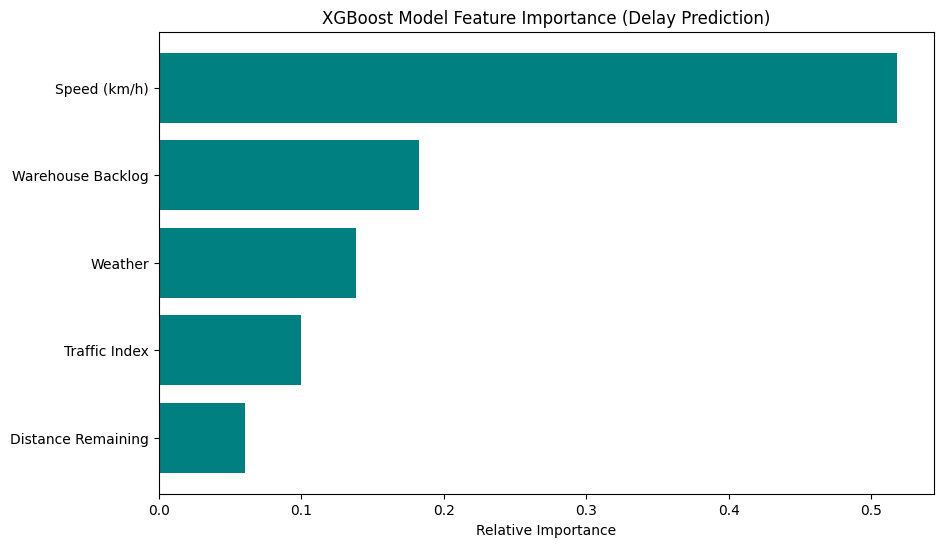

In [23]:
# Classifier Feature Importances
importances = pd.DataFrame({
    'Feature': ["Speed (km/h)", "Weather", "Traffic Index", "Warehouse Backlog", "Distance Remaining"],
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importances['Feature'], importances['Importance'], color='teal')
plt.title("XGBoost Model Feature Importance (Delay Prediction)")
plt.xlabel("Relative Importance")
plt.show()